In [3]:
import scopesim as sim
from scopesim.source.source import Source
sim.link_irdb("../..")

import numpy as np
from astropy.wcs import WCS
from astropy import units as u
import matplotlib.pyplot as plt
from synphot import SourceSpectrum

Set up the simulation in 'LSS' mode.

In [ ]:
cmd_lss = sim.UserCommands(use_instrument="UVEX", set_modes=['lss'])

# Can lower spectral bin width and resolution for the sake of time in this tutorial
cmd_lss["!SIM.spectral.spectral_bin_width"] = 1e-4 
cmd_lss["!SIM.spectral.spectral_resolution"] = 3000
cmd_lss["!SIM.computing.oversampling_x"] = 2
cmd_lss["!SIM.computing.oversampling_y"] = 2
cmd_lss["!SIM.computing.crop_y"] = [-400., 600.] # useful for fitting the image into memory: define with the source coordinates in mind

# Examine yaml bang strings
print(cmd_lss)

CurrSys contents:
├─OBS:
│ ├─instrument: UVEX
│ ├─modes: ['lss']
│ ├─dit: 300
│ └─ndit: 1
├─TEL:
│ ├─temperature: 0
│ └─telescope: UVEX
├─ATMO:
│ └─location: Space
├─INST:
│ ├─pixel_scale: 0.8
│ ├─plate_scale: 80
│ ├─decouple_detector_from_sky_headers: True
│ ├─fov_x0: 12600.0
│ ├─fov_y0: 0.0
│ └─fov_unit: arcsec
├─DET:
│ ├─detector: UVEX_CMOS_LSS
│ ├─image_plane_id: 0
│ ├─dit: !OBS.dit
│ ├─ndit: !OBS.ndit
│ └─gain: 1.2
└─SIM:
  ├─spectral:
  │ ├─spectral_bin_width: 0.0001
  │ ├─spectral_resolution: 3000
  │ ├─wave_min: 0.115
  │ ├─wave_mid: 0.235
  │ ├─wave_max: 0.355
  │ └─wave_unit: um
  ├─computing:
  │ ├─oversampling_x: 2
  │ ├─oversampling_y: 2
  │ ├─crop_x: [-13.2, 13.2]
  │ ├─crop_y: [-400.0, 600.0]
  │ └─crop_unit: arcsec
  └─random:
    └─seed: 9001

SystemDict contents:
├─SIM:
│ ├─spectral:
│ │ ├─wave_min: 0.3
│ │ ├─wave_mid: 2.2
│ │ ├─wave_max: 20
│ │ ├─wave_unit: um
│ │ ├─spectral_bin_width: 0.0001
│ │ ├─spectral_resolution: 5000
│ │ ├─minimum_throughput: 1e-06
│ │ └─minim

Print all effects and the order in which they get applied (z order).

In [5]:
opt = sim.OpticalTrain(cmd_lss)
om = opt.optics_manager
z_levels = np.arange(0, 1000, 100)
for z in z_levels:
    effs = om.get_z_order_effects(int(z))
    print(f"\nz-range {z}..{z+99}")
    for eff in effs:
        el = next(oe for oe in om.optical_elements if eff in oe.effects)
        print(f"{el.meta['name']:<20} | {eff.display_name:<20} | {eff.__class__.__name__:<20} | z_order={eff.z_order}")

py.warnings - WARNING: /Users/eshread/Desktop/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:169: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

astar.scopesim.utils - ERROR: File cannot be found: tbd_det_linearity.dat
astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits

z-range 0..99
UVEX                 | ota_surface_list     | SurfaceList          | z_order=(20, 120, 520)
LSS                  | relay_optics         | SurfaceList          | z_order=(20, 120, 520)
LSS                  | surfaces             | SurfaceList          | z_order=(20, 120, 520)
LSS                  | slit_geometry        | UVEXSlitMask         | z_order=(27, 227, 627)
LSS                  | spectral_traces      | SpectralTraceList    | z_order=(70, 270, 670)
uvex_lss_detector    | LSS_Detector         | DetectorList         | z_order=(90, 290, 390, 490)

z-range 100..199
UVEX                 |

Define the source. For this example, we will choose three stars at different positions but with the same Vega spectrum.

In [6]:
lam_array = np.arange(0.115, 0.355, 0.01)*u.um 
sp = SourceSpectrum.from_vega()

stars = Source(
    y=[-300., 0.0, 500.],          
    x=[12599.75, 12600., 12600.25],           
    ref=[0, 1, 2],           
    weight=[1.0, 1.0, 1.0], 
    spectra=[sp, sp, sp],
    lam=lam_array
)

py.warnings - WARNING: /Users/eshread/Desktop/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:169: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

astar.scopesim.utils - ERROR: File cannot be found: tbd_det_linearity.dat
astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits
py.warnings - WARNING: /Users/eshread/Desktop/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:211: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



 FOV effects:   0%|          | 0/8 [00:00<?, ?it/s]

 SpacecraftPointing effect convolution: 100%|██████████| 2340/2340 [00:08<00:00, 268.93it/s]


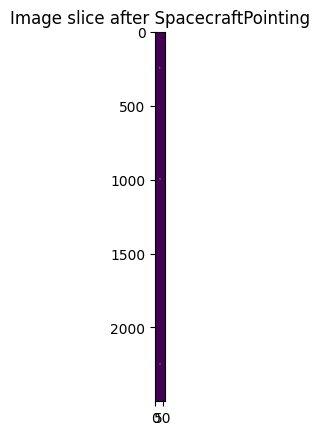

 Slit PSF Convolution: 128it [00:13,  9.26it/s]                        


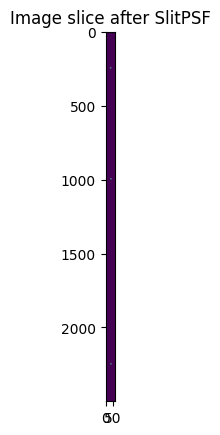

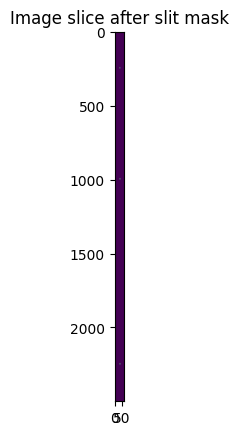

astar.scopesim.effects.apertures - Calculated slit throughput: 0.6873040164027793
astar.scopesim.effects.spectral_trace_list_utils - Loaded dispersion from file: /Users/eshread/Desktop/UVEX/uvex-mission/irdb/UVEX/data_files/UVIM_LSS_dispersion.dat
astar.scopesim.effects.spectral_trace_list_utils - WARNING: map_spectra_to_focal_plane: 4370117 negative pixels


 LSS Detector PSF Convolution: 28160it [01:12, 385.99it/s]                           


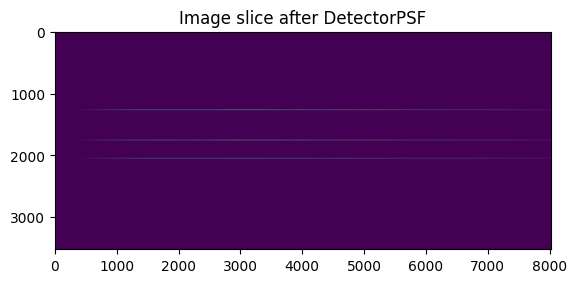

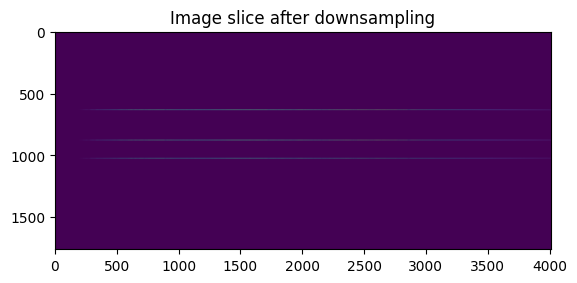

astar.scopesim.optics.image_plane - WARNING: No BUNIT found in added HDU.
astar.scopesim.detector.detector_manager - Extracting from 2 detectors...
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8268286 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8255532 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2


In [7]:
# Run the simulation
opt_lss = sim.OpticalTrain(cmd_lss)
opt_lss.observe(stars, update=True)
hdulist_lss = opt_lss.readout()[0]

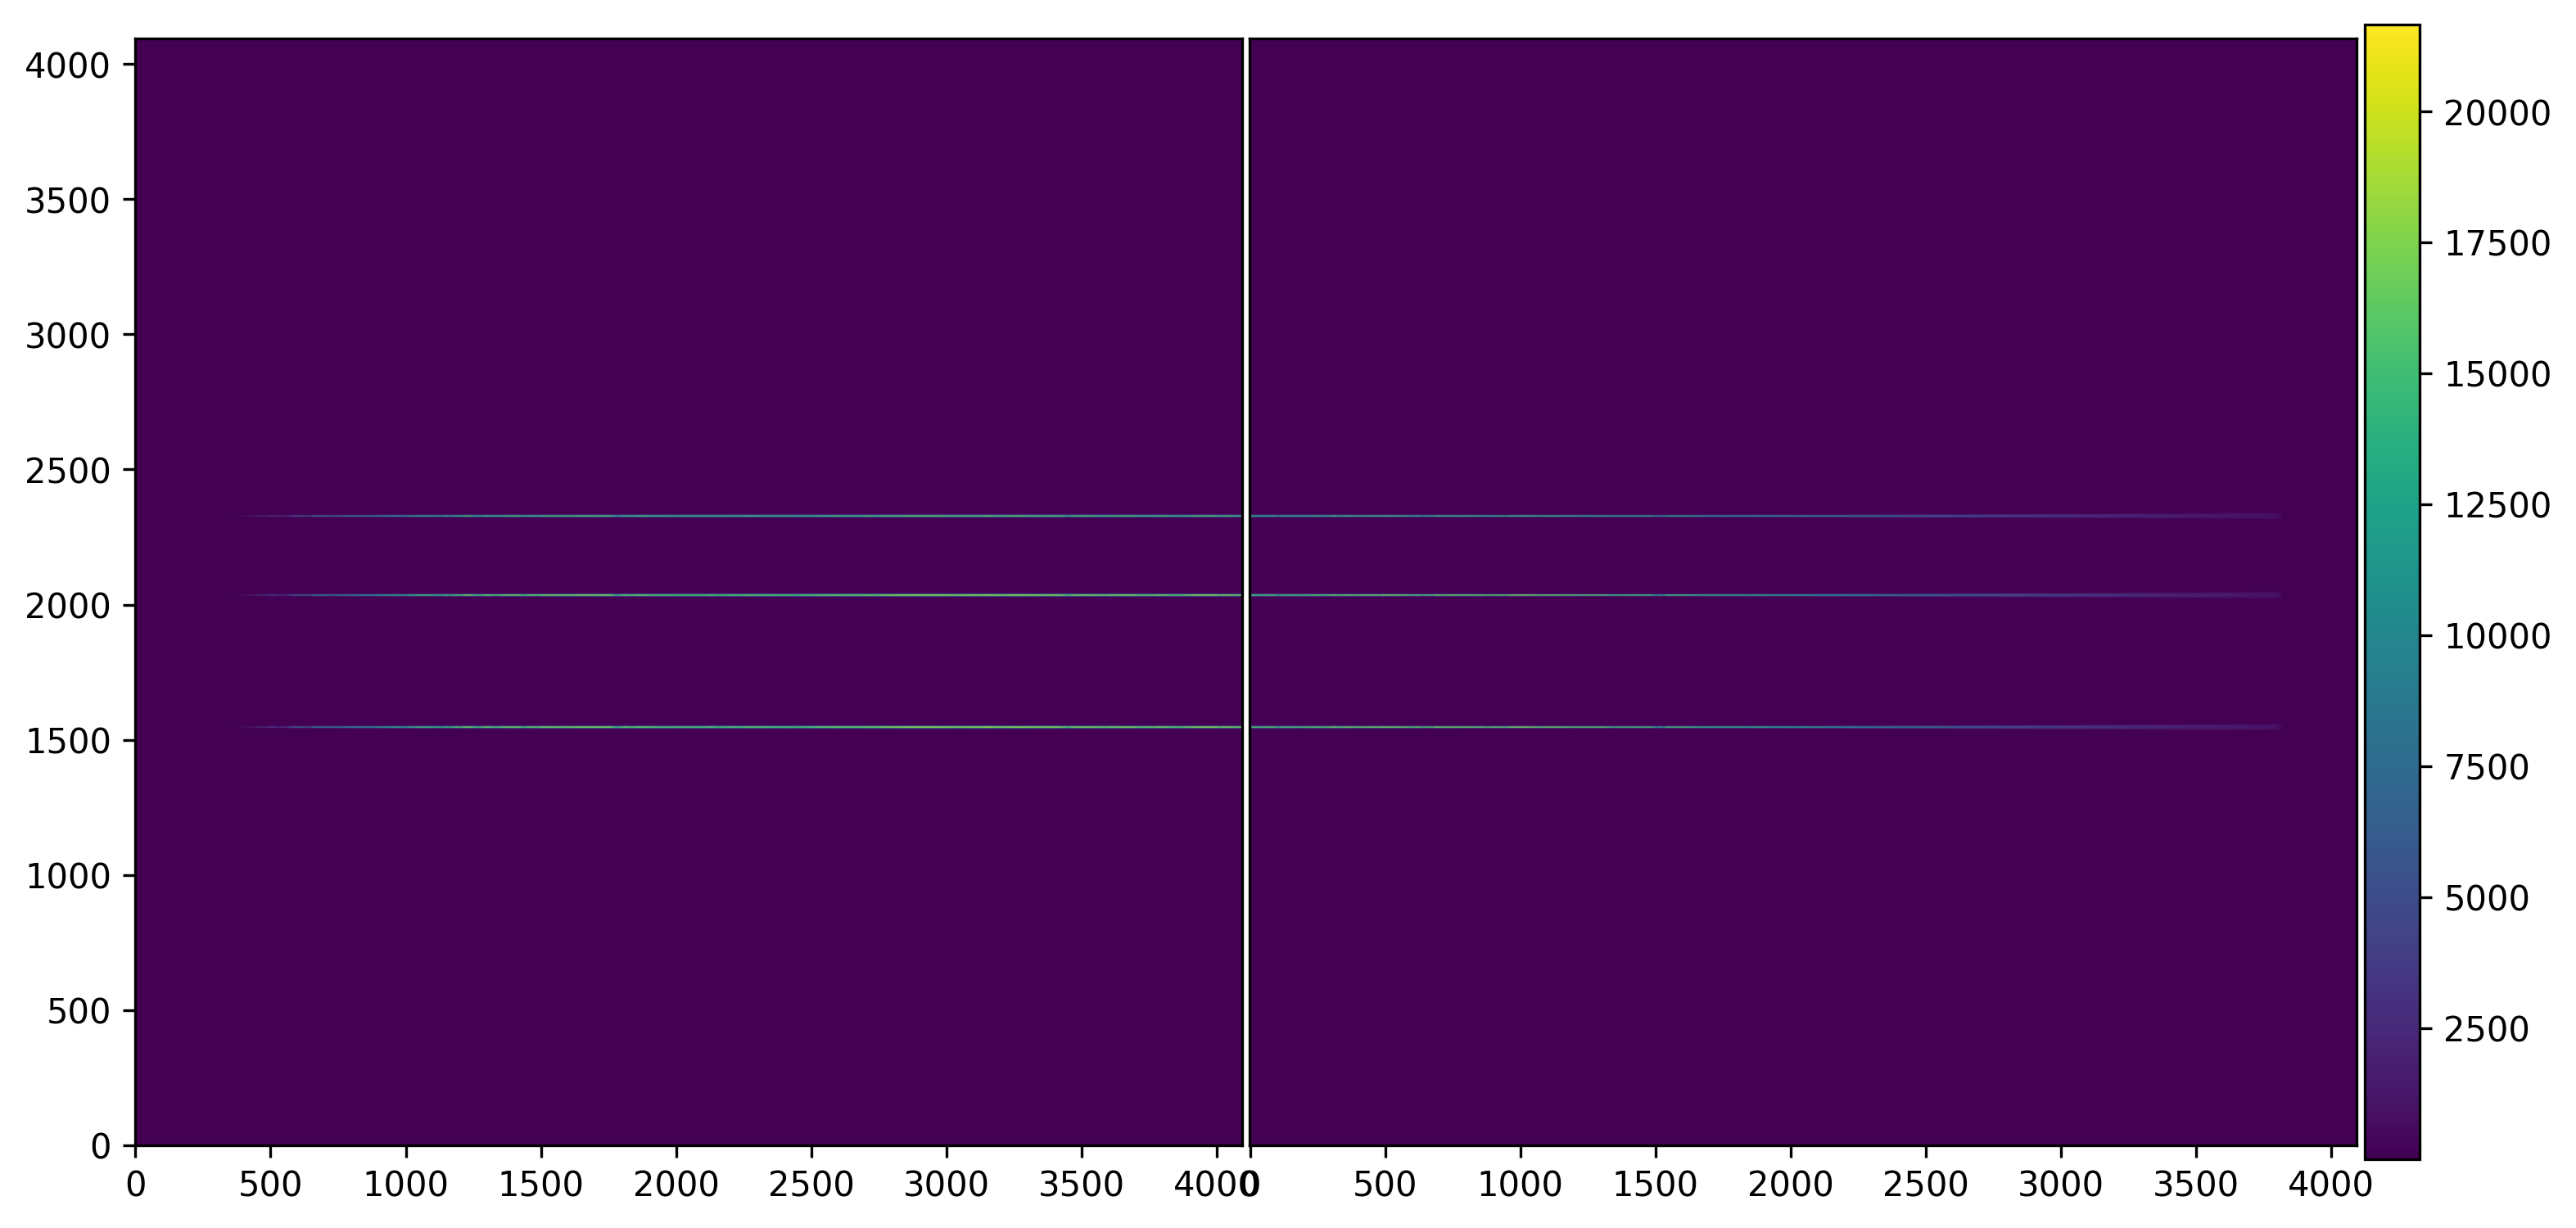

In [8]:
# Plot the output image
fig, axs = plt.subplots(ncols=3, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1, 0.05]}, dpi=300)
ax0, ax1, cax = axs
ax0.tick_params(axis="both", labelsize=10)
ax1.tick_params(axis="x", labelsize=10)
ax1.set_yticks([])

im0 = ax0.imshow(hdulist_lss[1].data, origin='lower')
im1 = ax1.imshow(hdulist_lss[2].data, origin='lower')

cbar = fig.colorbar(im1, cax=cax)
plt.subplots_adjust(wspace=0.01)
plt.show()

In [9]:
# Now rectify the spectra
tracelist = opt_lss["spectral_traces"]
rectified = tracelist.rectify_traces(hdulist_lss, xi_min=-550., xi_max=550.)

astar.scopesim.effects.spectral_trace_list - Full wavelength range: 0.12 .. 0.35 um


 Traces:   0%|          | 0/1 [00:00<?, ?it/s]

astar.scopesim.effects.spectral_trace_list_utils - Rectifying UVIM_LSS_trace (0.12 .. 0.35 um)
astar.scopesim.effects.spectral_trace_list_utils - Loaded dispersion from file: /Users/eshread/Desktop/UVEX/uvex-mission/irdb/UVEX/data_files/UVIM_LSS_dispersion.dat


[  63  133  160  164  293  294  295  296  297  298  299  300  301  302
  303  304  305  306  307  308  309  310  311  312  313  314  315  316
  317  318  319  320  321  322  323  324  325  326  327  328  329  330
  331  332  333  358  454  668  669  670  671  672  673  674  675  676
  677  678  679  680  681  682  683  684  685  686  687  688  689  690
  691  692  693  694  695  696  697  698  699  700  701  702  703  704
  705  706  707  708  715  836  896 1212 1293 1294 1295 1296 1297 1298
 1299 1300 1301 1302 1303 1304 1305 1306 1307 1308 1309 1310 1311 1312
 1313 1314 1315 1316 1317 1318 1319 1320 1321 1322 1323 1324 1325 1326
 1327 1328 1329 1330 1331 1332 1333]


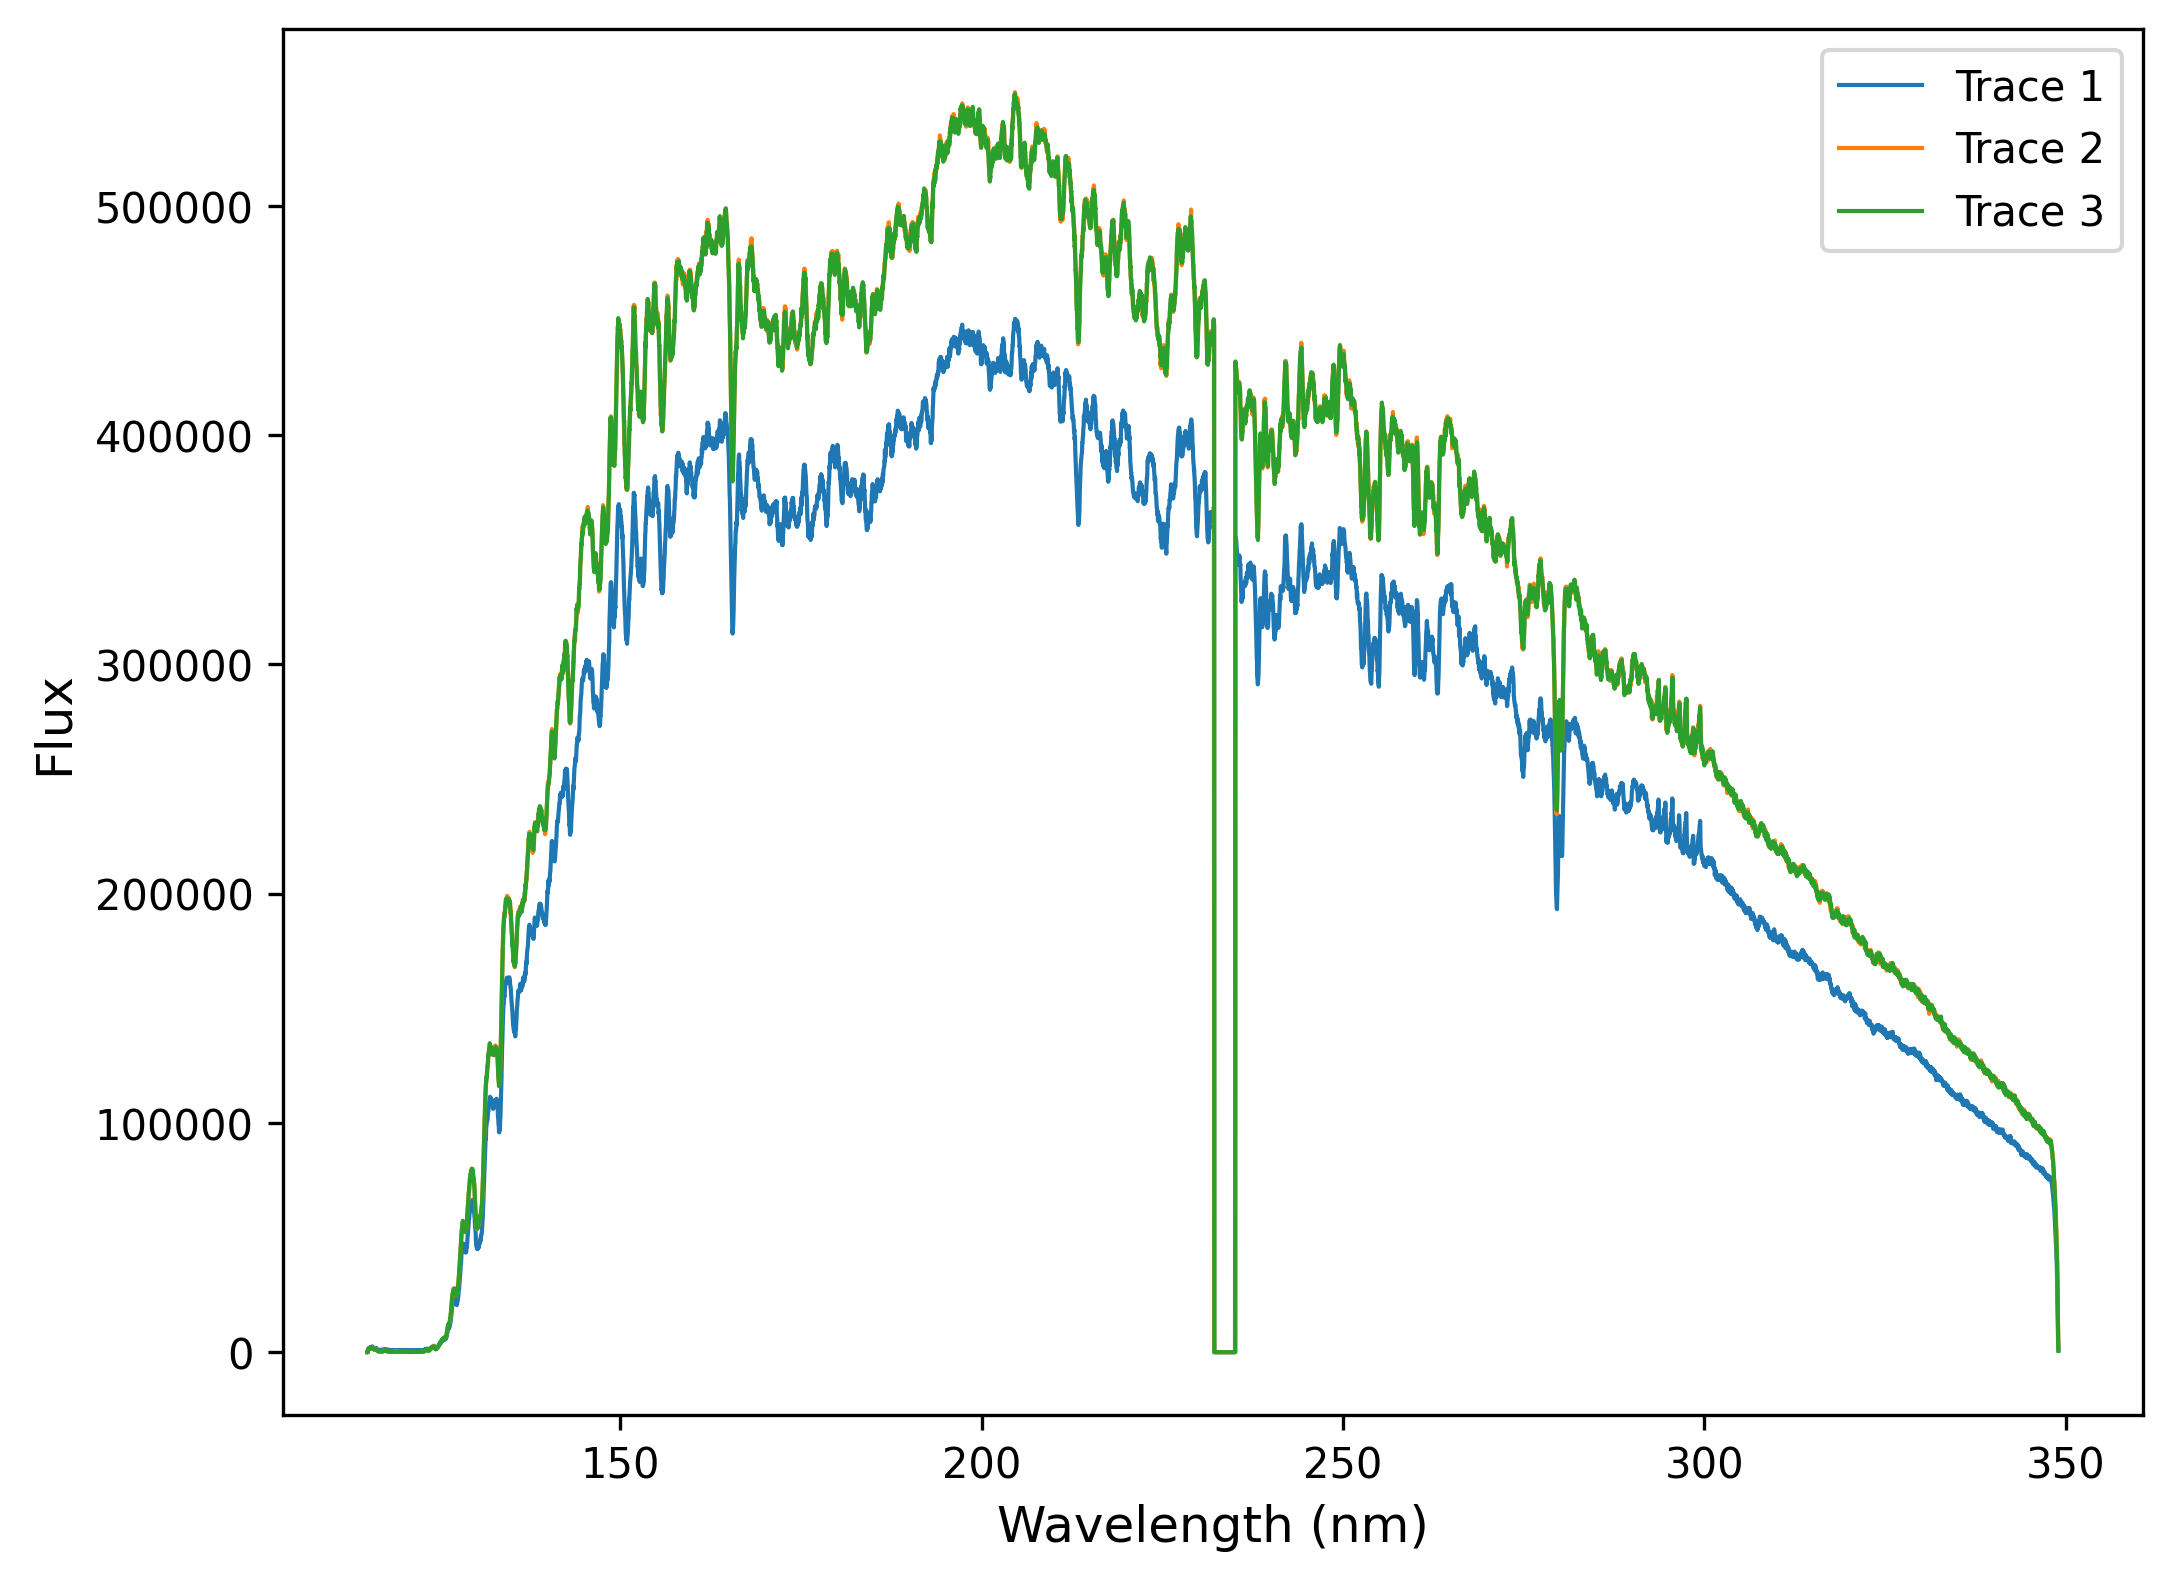

In [13]:
# Filter signal from noise manually
signal_y, signal_x = np.where(rectified[1].data > 40)

# Find the y indices of the traces
trace_indices = np.unique(signal_y)
print(trace_indices)

w = WCS(rectified[1].header)
n_lam = rectified[1].data.shape[1]
pix_x = np.arange(1, n_lam+1)
lam = w.all_pix2world(pix_x, np.ones_like(pix_x), 0)[0]
lam = np.array(lam)*10**9 # nm

# Select by eye for now
trace1 = rectified[1].data[63:334, :].sum(axis=0)
trace2 = rectified[1].data[668:709, :].sum(axis=0)
trace3 = rectified[1].data[1293:1334, :].sum(axis=0)

# Plot the 3 traces
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(lam, np.array(trace1), label="Trace 1", linewidth=1)
ax.plot(lam, np.array(trace2), label="Trace 2", linewidth=1)
ax.plot(lam, np.array(trace3), label="Trace 3", linewidth=1)
ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Flux", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.show()